## Chargement des données

In [6]:
# Manipulation de fichiers et texte
import os
import re
import unicodedata

# Calcul et manipulation de données
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Split des données
from sklearn.model_selection import train_test_split

# Représentation texte (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer

# Modèle baseline
from sklearn.naive_bayes import MultinomialNB

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

## chargement dse données 

In [7]:


def load_movies(path2data):
    """
    Cette fonction charge les critiques de films depuis un dossier.
    
    On suppose une structure du type :
        movies1000/
            neg/
            pos/

    Chaque sous-dossier correspond à une classe.
    """

    alltxts = []   # liste des textes
    labs = []      # liste des labels (0 ou 1)
    cpt = 0        # compteur de classe

    # Parcours des dossiers (neg, pos)
    for cl in sorted(os.listdir(path2data)):
        class_path = os.path.join(path2data, cl)

        # On vérifie que c'est bien un dossier
        if not os.path.isdir(class_path):
            continue

        # Parcours des fichiers texte
        for f in sorted(os.listdir(class_path)):
            file_path = os.path.join(class_path, f)

            if os.path.isfile(file_path):
                with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
                    txt = file.read()
                    alltxts.append(txt)
                    labs.append(cpt)

        # On passe à la classe suivante (0 → 1)
        cpt += 1

    return alltxts, labs


In [8]:

# UTILISATION DE LA FONCTION

movies_path = "./Dataset/movies1000/"

alltxts, alllabs = load_movies(movies_path)

print("Nombre de textes :", len(alltxts))
print("Nombre de labels :", len(alllabs))
print("Classes présentes :", set(alllabs))

Nombre de textes : 2000
Nombre de labels : 2000
Classes présentes : {0, 1}


## Nettoyage du texte

In [9]:

def clean_text(text,
               remove_accents=True,
               lowercase=True,
               remove_punctuation=True,
               remove_digits=True):
    """
    Nettoyage simple du texte.
    Pour cette première baseline, on garde un prétraitement léger
    afin de mieux interpréter les résultats.
    """

    # Suppression des accents
    if remove_accents:
        text = unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode("utf-8")

    # Passage en minuscules
    if lowercase:
        text = text.lower()
        text = text.replace("_", " ")

    # Suppression de la ponctuation
    if remove_punctuation:
        text = re.sub(r"[^\w\s]", " ", text)

    # Suppression des chiffres
    if remove_digits:
        text = re.sub(r"\d+", " ", text)

    # Suppression des espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

# On applique la fonction de nettoyage à tous les textes
texts_clean = [clean_text(t) for t in alltxts]

# test
print("texte original :\n")
print(alltxts[0][:80])

print("\n\ntexte nettoyé :\n")
print(clean_text(alltxts[0])[:80])

texte original :

plot : two teen couples go to a church party , drink and then drive . 
they get 


texte nettoyé :

plot two teen couples go to a church party drink and then drive they get into an


## Représentation BoW + taille du vocabulaire

- Pour cette première exploration, on utilise un BoW classique.
- Chaque document est transformé en vecteur de comptage de mots.

In [10]:
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(texts_clean)

# Récupération du vocabulaire
vocab = np.array(vectorizer_bow.get_feature_names_out())

print("Shape de la matrice BoW :", X_bow.shape)
print("Taille du vocabulaire :", len(vocab))

print("Exemple de mots du vocabulaire :")
print(vocab[:20])

Shape de la matrice BoW : (2000, 38885)
Taille du vocabulaire : 38885
Exemple de mots du vocabulaire :
['aa' 'aaa' 'aaaaaaaaah' 'aaaaaaaahhhh' 'aaaaaah' 'aaaahhhs' 'aahs'
 'aaliyah' 'aalyah' 'aamir' 'aardman' 'aaron' 'aatish' 'ab' 'aback'
 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abandons']


- Cette étape permet de passer du texte brut à une représentation numérique.
- Ici, chaque mot du vocabulaire devient une dimension dans l'espace vectoriel.
- La taille du vocabulaire donne déjà une première idée de la complexité du corpus.

## Top mots les plus fréquents

In [11]:

# On calcule le nombre total d'occurrences de chaque mot
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()

# On trie les mots par fréquence décroissante
top_idx = np.argsort(word_counts)[::-1][:100]

print("top 20 mots les plus fréquents :")

for w, c in zip(vocab[top_idx][:20], word_counts[top_idx][:20]):
    print(f"{w} : {c}")

top 20 mots les plus fréquents :
the : 76574
and : 35581
of : 34126
to : 31939
is : 25203
in : 21827
it : 16110
that : 15927
as : 11378
with : 10792
for : 9961
his : 9588
this : 9579
film : 9519
he : 8864
but : 8636
on : 7387
are : 6950
by : 6262
be : 6174


- Cette étape permet d'identifier les mots les plus présents dans le corpus.
-  On s'attend généralement à retrouver des mots très fréquents mais peu informatifs,
- comme des mots communs du langage (ex : "the", "and").

## Fréquence documentaire

In [12]:
# On compte dans combien de documents chaque mot apparaît
# (et non pas combien de fois il apparaît au total)

doc_freq = np.asarray((X_bow > 0).sum(axis=0)).ravel()

# Tri décroissant
top_df_idx = np.argsort(doc_freq)[::-1][:100]

print("top 20 mots les plus fréquents en nombre de documents :")

for w, c in zip(vocab[top_df_idx][:20], doc_freq[top_df_idx][:20]):
    print(f"{w} : {c}")

top 20 mots les plus fréquents en nombre de documents :
the : 1999
of : 1998
and : 1998
to : 1997
is : 1995
in : 1994
it : 1967
that : 1963
with : 1944
for : 1922
as : 1920
but : 1903
this : 1896
on : 1861
an : 1785
by : 1782
are : 1781
one : 1776
be : 1774
his : 1756


## Split train / test

In [13]:
# On garde 80% des données pour l'entraînement
# et 20% pour le test local
# Le paramètre stratify permet de conserver la proportion des classes

txt_train, txt_test, y_train, y_test = train_test_split(
    texts_clean,
    alllabs,
    test_size=0.2,
    random_state=42,
    stratify=alllabs
)

print("Taille du train :", len(txt_train))
print("Taille du test  :", len(txt_test))
print("Classes dans y_train :", set(y_train))
print("Classes dans y_test  :", set(y_test))

Taille du train : 1600
Taille du test  : 400
Classes dans y_train : {0, 1}
Classes dans y_test  : {0, 1}


## Vectorisation BoW sur train / test

In [14]:
# On apprend le vocabulaire uniquement sur le train
# puis on applique la même transformation au test

vectorizer_train = CountVectorizer()

X_train = vectorizer_train.fit_transform(txt_train)
X_test = vectorizer_train.transform(txt_test)

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Taille du vocabulaire train :", len(vectorizer_train.get_feature_names_out()))

Shape X_train : (1600, 35688)
Shape X_test  : (400, 35688)
Taille du vocabulaire train : 35688


## Entraînement et evaluation du modèle Naive Bayes

===== RÉSULTATS - BOW + NAIVE BAYES =====
Accuracy : 0.8150
F1-score : 0.8159
AUC      : 0.8852


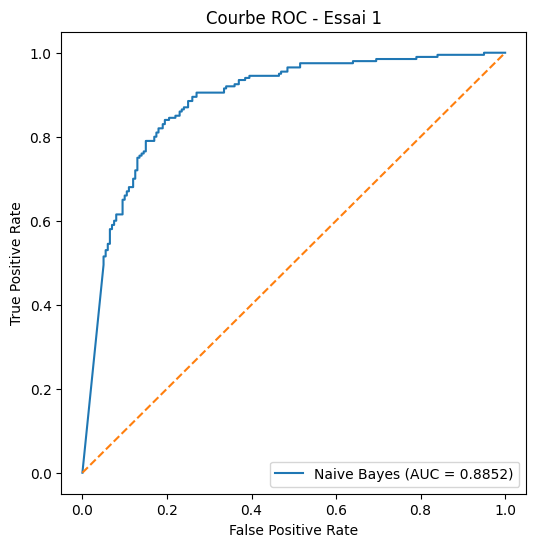

In [15]:
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Prédictions sur le jeu de test local
y_pred = model_nb.predict(X_test)

# Scores de probabilité pour la classe positive
y_scores = model_nb.predict_proba(X_test)[:, 1]

# Calcul des métriques demandées
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_scores)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
print("===== RÉSULTATS - BOW + NAIVE BAYES =====")
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")


plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Naive Bayes (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Essai 1")
plt.legend()
plt.show()

## Réentraînement sur tout le dataset

In [16]:

# Après l'évaluation locale, on réentraîne le modèle
# sur l'ensemble complet des données disponibles.
# L'idée est d'utiliser un maximum d'information avant la soumission finale.

vectorizer_final = CountVectorizer()
X_full = vectorizer_final.fit_transform(texts_clean)
y_full = np.array(alllabs)

model_nb_final = MultinomialNB()
model_nb_final.fit(X_full, y_full)

print("Shape X_full :", X_full.shape)

Shape X_full : (2000, 38885)


## Génération du CSV de soumission

In [21]:
test_texts = txt_test  # on utilise le test local

y_pred_final = model_nb_final.predict(
    vectorizer_final.transform([clean_text(t) for t in test_texts])
)

submission = ["P" if pred == 1 else "N" for pred in y_pred_final]

with open("movie_essai1.csv", "w", encoding="utf-8") as f:
    for label in submission:
        f.write(label + "\n")

print("CSV prêt ✅")


CSV prêt ✅
